In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Total Chemical Potential

The total chemical potential in a fluid is given by:

$\mu = \mu_\text{id} + \mu_\text{ex}$

- $\mu_\text{id}$ is the ideal gas contribution,
- $\mu_\text{ex}$ is the excess chemical potential due to
    intermolecular interactions.

# Ideal Gas Contribution

The ideal gas chemical potential is:

$\mu_\text{id} = k_B T \ln(\rho \Lambda^3)$

where $\rho = N/V$ is the number density and $\Lambda$ is the thermal de Broglie wavelength:

$\Lambda = \sqrt{\frac{h^2}{2 \pi m k_B T}}$

- $h = 6.626 \times 10^{-34}\ \mathrm{J\ s}$ (Planck's constant),
- $m = \frac{39.962\ \mathrm{g/mol}}{6.022 \times 10^{23}}\approx 6.64\times 10^{-26}\ \mathrm{kg}$ (mass of one argon atom),
- $k_B = 1.3806 \times 10^{-23}\ \mathrm{J/K}$ (Boltzmann constant),
- $T = 84$ K.

$\to \Lambda = 0.307 \mathrm{\AA{}}$

In [48]:
mu_vs_N_gcmc = np.loadtxt("GCMC-chemical-potential/number_vs_mu.dat")
p_vs_N_gcmc = np.loadtxt("GCMC-imposed-pressure/number_vs_pressure.dat")
muex_vs_N_widom = np.loadtxt("Widom-fixed-number/number_vs_muex.dat")

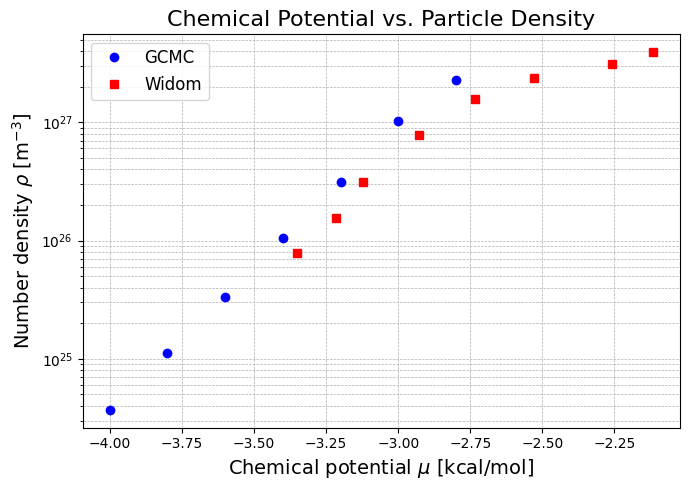

In [45]:
# From GCMC
N = mu_vs_N_gcmc[:,1] # number of particle in box
mu = mu_vs_N_gcmc[:,0] # chemical potential in kcal/mol
V = (40e-10)**3 # volume in m3
rho = N/V # particles per m3

plt.figure(figsize=(7,5))

plt.semilogy(mu, rho, 'o', label=r'GCMC', markersize=6, color='blue')

# From Widom
N = muex_vs_N_widom[:,1] # number of particle in box
mu_ex = muex_vs_N_widom[:,0] # excess chemical potential in kcal/mol
V = (40e-10)**3 # volume in m3
rho = N/V # particles per m3

Lambda = 0.3077e-10 # de Broglie wavelenght in m
T = 84 # K
kB = 1.987e-3 # kcal/mol/K
mu_id = kB*T * np.log(rho*Lambda**3)

mu = mu_id + mu_ex

plt.semilogy(mu, rho, 's', label=r'Widom', markersize=6, color='red')

# Labels and legend
plt.xlabel(r'Chemical potential $\mu$ [kcal/mol]', fontsize=14)
plt.ylabel(r'Number density $\rho$ [m$^{-3}$]', fontsize=14)
plt.title(r'Chemical Potential vs. Particle Density', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", linewidth=0.5)

# Optional: tight layout for better spacing
plt.tight_layout()
plt.show()

# Link between fugacity and chemical potential

$\mu = k_\mathrm{B} T \ln f$

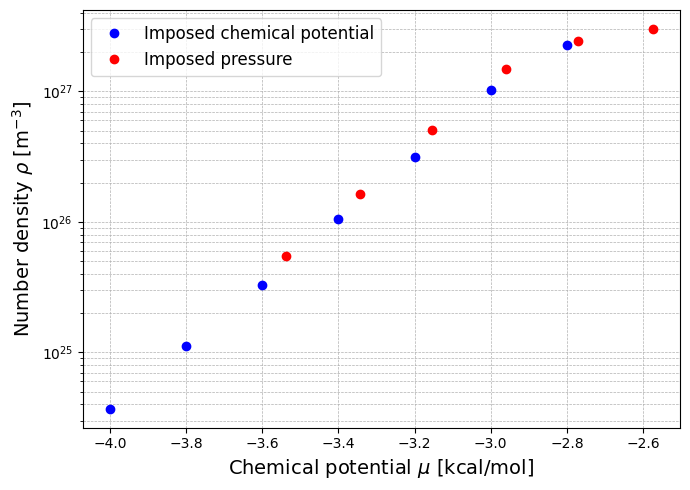

In [81]:
# From GCMC
N = mu_vs_N_gcmc[:,1] # number of particle in box
mu = mu_vs_N_gcmc[:,0] # chemical potential in kcal/mol
V = (40e-10)**3 # volume in m3
rho = N/V # particles per m3

plt.figure(figsize=(7,5))

plt.semilogy(mu, rho, 'o', label=r'Imposed chemical potential', markersize=6, color='blue')

p = p_vs_N_gcmc[:,0]
N = p_vs_N_gcmc[:,1]

p0 = 500000 # atm

mu = kB*T * np.log(p/p0)
rho = N/V # particles per m3

plt.semilogy(mu, rho, "o", label=r'Imposed pressure', markersize=6, color='red')

plt.xlabel(r'Chemical potential $\mu$ [kcal/mol]', fontsize=14)
plt.ylabel(r'Number density $\rho$ [m$^{-3}$]', fontsize=14)

plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", linewidth=0.5)

# Optional: tight layout for better spacing
plt.tight_layout()
plt.show()

In [82]:
p

array([0.031  , 0.01   , 0.00031, 0.0031 , 0.1    , 0.001  ])

In [20]:
N 

array([  2.11111111,  20.06296296,   6.68518519, 144.63111111,
         0.72222222,   0.23703704,  65.24444444])